You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L07_frequentist.ipynb)

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
from sklearn.neighbors import KernelDensity
import astropy.visualization.hist

The irreducible mass of a black hole is defined as

$$M_{irr} = M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}},$$

where the variables $M,\chi$ are distributed according to $\mathcal N(\mu=1,\sigma)$ and uniform(0,1), respectively, and are uncorrelated.

# Task 1, 2

In [2]:
mu, sigma_0 = 1, 0.02
N = 10**3 #sample size

We generate two random samples, one for each variable.

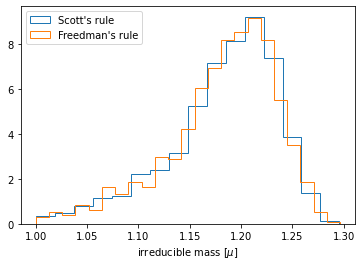

In [3]:
Mi = stats.norm.rvs(loc=mu, scale=sigma_0, size=N)
chi_i = stats.uniform.rvs(size=N)
#------------------
points = np.stack((Mi,chi_i),axis=-1) #points in the 2D variable space
#------------------
def irr(data):
    m_irr = data[:,0] * np.sqrt(1+np.sqrt(1-data[:,1]**2)/2)
    return m_irr
Mirr_i = irr(points)
#------------------
astropy.visualization.hist(Mirr_i, bins="scott", histtype="step",density=True,label="Scott's rule")
astropy.visualization.hist(Mirr_i, bins="freedman", histtype="step",density=True,label="Freedman's rule")
plt.xlabel(f'irreducible mass $[\mu]$')
plt.legend(loc='upper left')
plt.show()

# Task 3: PDF-density estimation through KDE

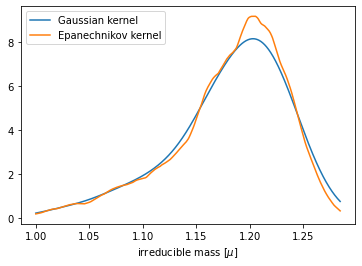

In [4]:
xgrid = np.linspace(Mirr_i.min(),Mirr_i.max(),1000)
#------------------
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)
#------------------
PDF_gaussian = kde_sklearn(Mirr_i,bandwidth=0.02,kernel="gaussian")
PDF_epanechnikov = kde_sklearn(Mirr_i,bandwidth=0.02,kernel="epanechnikov")
#------------------
plt.plot(xgrid,PDF_gaussian,label='Gaussian kernel') 
plt.plot(xgrid,PDF_epanechnikov,label='Epanechnikov kernel') 
plt.xlabel(f'irreducible mass $[\mu]$')
plt.legend(loc='upper left')
plt.show()

# Task 4, 5: KS-tests

We first evaluate the compatibility between the $M_{irr}$ sample and 

$$f(\chi) \equiv \frac{M_{irr}}{M} = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}},$$

then between the $M_{irr}$ sample and $M$. To do so, we marginalize the empirical PDF of $M_{irr}$ over $M$ and $\chi$, respectively.

### ($M_{irr},f$)

In [14]:
#fill a (M,N)-array, where M is the number of σs and each row contains an N-size sample of M_irr for a given σ
M, k = 200, 50000 # k*sigma_0 is the upper bound for σ
sigma = sigma_0 * 10**np.arange(-2.0, 5.0)
#sigma = sigma_0 * np.linspace(1, k, M)
Mi_var = np.array([stats.norm.rvs(loc=mu, scale=s, size=N) for s in sigma])
chi_i_var = np.reshape((np.repeat(chi_i,M)),(M,N))

If no element is repeated in either sample (`Mi_var`, `chi_i_var`), that is for every element in `Mi_var` there's one and only one element in `chi_i_var`, we can avoid the nuisance of marginalization.

In [6]:
#check that no element is repeated in either sample
print(np.unique(Mi_var).size==Mi_var.size,np.unique(chi_i).size==chi_i.size)

True True


In [7]:
#define f
def f(data):
    return np.sqrt(1+np.sqrt(1-data**2)/2)

In [15]:
points_var = np.array([np.stack((mi,chi_i),axis=-1) for mi in Mi_var])
Mirr_i_var = np.array([irr(p) for p in points_var])

$p$-values for KS-test on $(M_{irr},M)$ and $(M_{irr},f(\chi))$ for varying $\sigma$

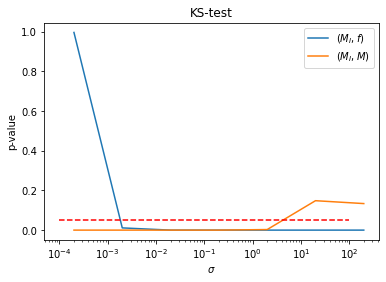

In [16]:
p_value_M = np.array([stats.ks_2samp(m,p[:,0])[1] for m,p in zip(Mirr_i_var,points_var)])
p_value_f = np.array([stats.ks_2samp(m,f(p[:,1]))[1] for m,p in zip(Mirr_i_var,points_var)])
#------------------
fig, ax = plt.subplots()
plt.plot(sigma, p_value_f, label='($M_I,f$)');
plt.plot(sigma, p_value_M, label='$(M_I,M)$');
ax.plot([1e-4, 1e2],[0.05, 0.05], '--r')
plt.xscale('log')
plt.xlabel('$\sigma$')
plt.ylabel('p-value')
plt.legend()
plt.title('KS-test')
plt.show()

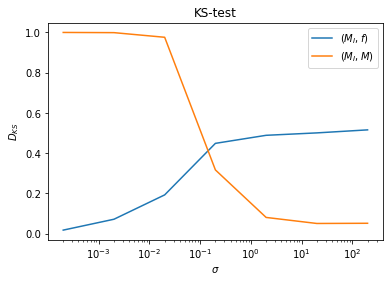

In [19]:
test_value_M = np.array([stats.ks_2samp(m,p[:,0])[0] for m,p in zip(Mirr_i_var,points_var)])
test_value_f = np.array([stats.ks_2samp(m,f(p[:,1]))[0] for m,p in zip(Mirr_i_var,points_var)])
#------------------
fig, ax = plt.subplots()
plt.plot(sigma, test_value_f, label='($M_I,f$)');
plt.plot(sigma, test_value_M, label='$(M_I,M)$');
plt.xscale('log')
plt.xlabel('$\sigma$')
plt.ylabel('$D_{KS}$')
plt.legend()
plt.title('KS-test')
plt.show()

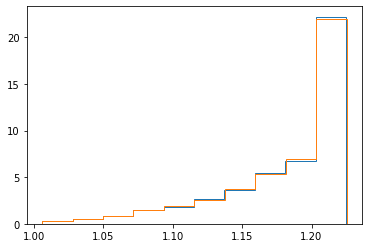

In [10]:
plt.hist(f(points_var[0][:,1]),density=True,histtype='step');
plt.hist(Mirr_i_var[0],density=True,histtype='step')
plt.show()

`stats.ks_2samp(,)[0]` returns $\lambda=D\sqrt{N}$ and not $D$!!!